# 08. Averaging over an ensemble of runs

**Goal.** MD is stochastic: one trajectory is one sample. Run `Process` on several independent runs and let `Graphing.Read_Meta` average them with error bands.

**You need.** Tutorial 05. Uses `data.synthetic()` — seeded ASE/EMT Langevin MD of a small Cu cluster — so it runs in seconds with no download.


## 8.1 Make an ensemble

`Sapphire.Tutorials.data.synthetic(seed=…)` gives short, reproducible trajectories. EMT is a toy
potential, but the workflow is exactly the one you would use with your own runs: one directory per
run, identical `System`/`Quantities`.

In [1]:
import os, numpy as np, matplotlib.pyplot as plt
from Sapphire import Process
from Sapphire.Tutorials import data

base = os.path.abspath("ensemble") + "/"
runs = ["seed0", "seed1", "seed2"]
for k, run in enumerate(runs):
    d = base + run + "/"; os.makedirs(d, exist_ok=True)
    data.synthetic(n_frames=30, element="Cu", noshells=3, temperature_K=900.0, seed=k, out=d + "movie.xyz")   # 147-atom Cu Ih
    System = {"base_dir": d, "movie_file_name": "movie.xyz", "extend_xyz": None, "Homo": None, "Hetero": False,
              "Start": 0, "End": 30, "Step": 3, "Skip": 1, "UniformPDF": False, "Band": 0.05}
    Process.Process(System=System, Quantities={"Full": {"pdf": None, "rdf": None, "adj": None, "nn": None, "agcn": None, "cna_sigs": None, "gyration": None}}).analyse({"JSD": ["pdf"]})
print("done:", runs)

done: ['seed0', 'seed1', 'seed2']


## 8.2 Average with `Read_Meta`

`iter_dir` lists the run sub-directories; `Average()` returns per-quantity means and standard deviations
across runs (the same shapes as a single run). `Plot_Funcs` draws the std as a band when `Errors` is given.

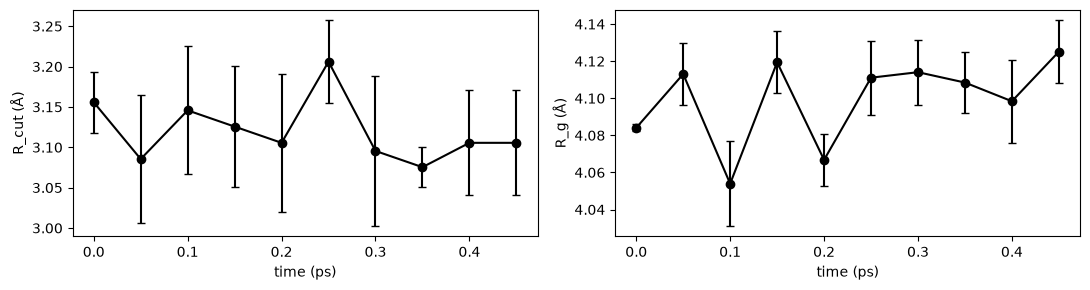

In [2]:
from Sapphire.Graphing import Reader as GReader, Plot_Funcs
PS = {"base_dir": base, "iter_dir": runs, "plot_dir": "Images/", "frame_dt": 0.05}          # 10 steps x 5 fs per frame
avg, err = GReader.Read_Meta(PS).Average()
t = avg["SimTime"]
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].errorbar(t, avg["R_Cut"], err["R_Cut"], fmt="ko-", capsize=3); ax[0].set_ylabel("R_cut (Å)")
ax[1].errorbar(t, avg["gyration"], err["gyration"], fmt="ko-", capsize=3); ax[1].set_ylabel("R_g (Å)")
for a in ax: a.set_xlabel("time (ps)")
plt.tight_layout(); plt.show()

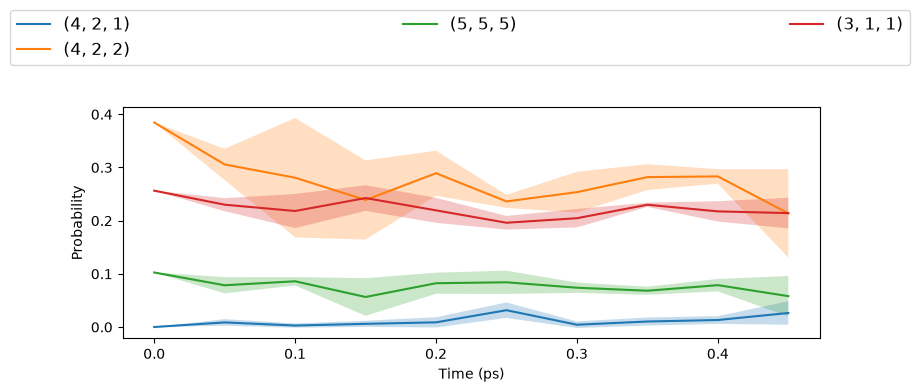

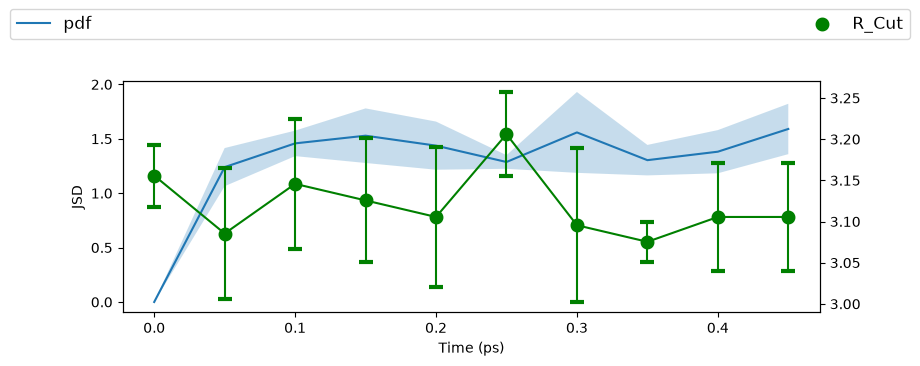

In [3]:
Plot_Funcs.Plot_Funcs(avg, Quantities={"cna_traj": {"Sigs": [(4,2,1), (4,2,2), (5,5,5), (3,1,1)]},
                                        "plot_stats": {"Stats": ["JSD"], "Quants": ["pdf"]}}, System=PS, Errors=err).Make_Plots()
from IPython.display import Image, display
display(Image(base + "Images/CNA_Traj.png")); display(Image(base + "Images/JSD.png"))

## 8.3 Temperature averaging

The same machinery averages over *frames* at the same temperature instead of over runs: for a
heating ramp, group frames by T (e.g. 50 K bins) and treat each group as the "ensemble". With the
adapter's arrays this is a numpy `groupby`:

In [4]:
T = 300 + 50 * np.arange(len(t))          # pretend ramp for illustration
bins = (T // 100) * 100
for b in np.unique(bins):
    sel = bins == b
    print(f"T in [{b}, {b+100}) K: R_cut = {avg['R_Cut'][sel].mean():.3f} ± {avg['R_Cut'][sel].std():.3f} Å  ({sel.sum()} frames)")

T in [300, 400) K: R_cut = 3.121 ± 0.035 Å  (2 frames)
T in [400, 500) K: R_cut = 3.136 ± 0.010 Å  (2 frames)
T in [500, 600) K: R_cut = 3.156 ± 0.050 Å  (2 frames)
T in [600, 700) K: R_cut = 3.085 ± 0.010 Å  (2 frames)
T in [700, 800) K: R_cut = 3.106 ± 0.000 Å  (2 frames)


## 8.4 Try it

* Increase `n_frames` and the number of seeds; the error bands shrink like 1/√n.
* Swap EMT for a machine-learned potential (see `docs/ML_POTENTIALS.md`) — the workflow is unchanged.
* For real ensembles: the full data release has two independent runs per system (`Sim-1345`, `Sim-3987`).

*This concludes the tutorial series.* The `examples/` directory holds script versions of the
trajectory workflow (`run_analysis.py`, `plot_results.py`, `from_lammps.py`, `make_figures.py`).